In [2]:
import shap
import joblib
import pandas as pd
import numpy as np

In [3]:
model = joblib.load(
    "../models/multiclass_xgb_v1.pkl"
)

print(type(model))


<class 'xgboost.sklearn.XGBClassifier'>


In [4]:
df = pd.read_csv(
    "../data/processed/multiclass_balanced.csv"
)

print(df.shape)

(856509, 81)


In [5]:
X = df.drop(
    ["Label", "AttackFamily", "Target"],
    axis=1
)

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(0)

print(X.shape)

(856509, 78)


In [6]:
sample = X.sample(
    500,
    random_state=42
)

sample.shape

(500, 78)

In [7]:
explainer = shap.TreeExplainer(
    model
)

In [8]:
shap_values = explainer.shap_values(
    sample
)

In [9]:
type(shap_values)

numpy.ndarray

In [10]:
shap_values.shape

(500, 78, 7)

In [11]:
ddos_shap = shap_values[:, :, 3]

ddos_shap.shape

(500, 78)

In [12]:
feature_importance = pd.DataFrame({
    "Feature": sample.columns,
    "Importance": np.abs(ddos_shap).mean(axis=0)
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
68,act_data_pkt_fwd,1.336853
8,Fwd Packet Length Mean,0.907097
69,min_seg_size_forward,0.709057
5,Total Length of Bwd Packets,0.488737
6,Fwd Packet Length Max,0.408589
0,Destination Port,0.378641
66,Init_Win_bytes_forward,0.278987
4,Total Length of Fwd Packets,0.278902
67,Init_Win_bytes_backward,0.248011
40,Packet Length Mean,0.219652


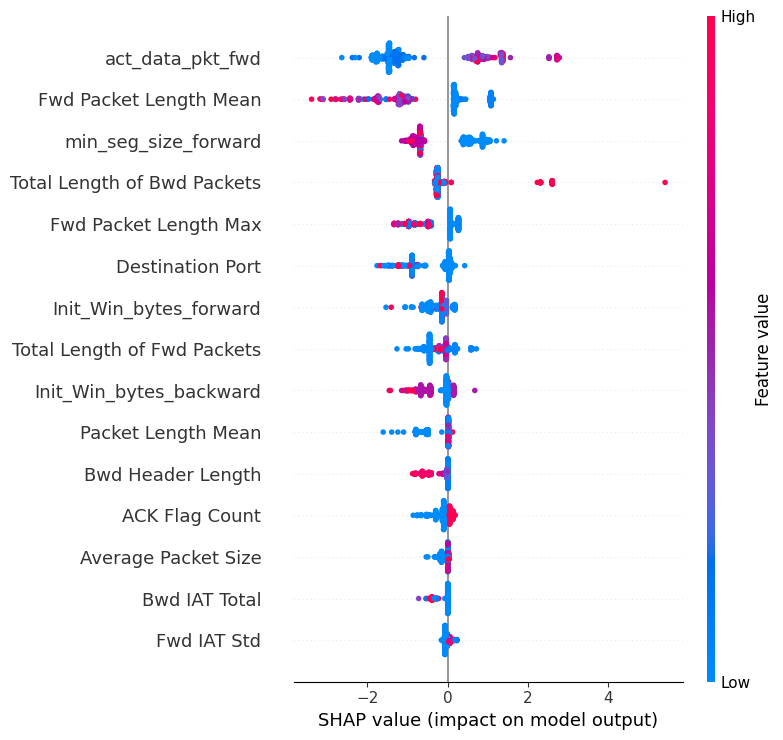

In [13]:
shap.summary_plot(
    ddos_shap,
    sample,
    max_display=15
)

In [14]:
import matplotlib.pyplot as plt

shap.summary_plot(
    ddos_shap,
    sample,
    max_display=15,
    show=False
)

plt.savefig(
    "../docs/shap_ddos_summary.png",
    bbox_inches="tight",
    dpi=300
)

plt.close()